In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [19]:
image_paths = list(Path("input").glob("*"))
for i in image_paths:
    print(i)

input\image1.jpg
input\image2.png
input\image3.jpg
input\sample.png


In [21]:
import cv2
import numpy as np
import os

def load_image(path):
    img_array = np.fromfile(path, dtype=np.uint8)
    img_bgr = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb

images = [load_image(path) for path in image_paths]

In [22]:
mean_kernel = np.ones((3, 3), dtype=np.float32) / 9
print("Mean kernel:")
print(mean_kernel)

Mean kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


In [23]:
g1 = cv2.getGaussianKernel(5, 1)
gaussian_kernel = g1 @ g1.T

print("Gaussian kernel:")
print(gaussian_kernel)

Gaussian kernel:
[[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]


In [24]:
laplacian_kernel = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype=np.float32)

print("Laplacian kernel:")
print(laplacian_kernel)

Laplacian kernel:
[[ 0.  1.  0.]
 [ 1. -4.  1.]
 [ 0.  1.  0.]]


In [25]:
kx, ky = cv2.getDerivKernels(
    dx=1,
    dy=0,
    ksize=3,
    normalize=False
)

sobel_x_kernel = ky @ kx.T

print("Sobel X kernel:")
print(sobel_x_kernel)

Sobel X kernel:
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]


In [26]:
kx, ky = cv2.getDerivKernels(
    dx=0,
    dy=1,
    ksize=3,
    normalize=False
)

sobel_y_kernel = ky @ kx.T

print("Sobel Y kernel:")
print(sobel_y_kernel)

Sobel Y kernel:
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]


In [27]:
def apply_filters(img_rgb):

    # =========================
    # LOW-PASS FILTER
    # =========================

    mean_filtered = cv2.filter2D(
        img_rgb,
        ddepth=-1,
        kernel=mean_kernel
    )

    # Gaussian filter
    gaussian_filtered = cv2.GaussianBlur(
        img_rgb,
        ksize=(5, 5),
        sigmaX=1
    )

    # =========================
    # HIGH-PASS FILTER
    # =========================

    # High-pass thường dễ quan sát hơn trên ảnh grayscale
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    laplacian = cv2.filter2D(
        gray.astype(np.float32),
        ddepth=cv2.CV_32F,
        kernel=laplacian_kernel
    )

    laplacian = np.abs(laplacian)
    laplacian = cv2.normalize(
        laplacian,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    # Sobel X
    sobel_x = cv2.filter2D(
        gray.astype(np.float32),
        cv2.CV_32F,
        sobel_x_kernel
    )

    # Sobel Y
    sobel_y = cv2.filter2D(
        gray.astype(np.float32),
        cv2.CV_32F,
        sobel_y_kernel
    )
    sobel = np.sqrt(sobel_x**2 + sobel_y**2)

    sobel = cv2.normalize(
        sobel,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    return {
        "Original": img_rgb,
        "Mean": mean_filtered,
        "Gaussian": gaussian_filtered,
        "Laplacian": laplacian,
        "Sobel": sobel
    }

In [30]:
import os
import cv2
import matplotlib.pyplot as plt

def save_image_unicode(path, img):
    """Hàm hỗ trợ lưu ảnh an toàn trên Windows (kể cả đường dẫn có tiếng Việt)"""
    ext = os.path.splitext(path)[1]
    if img.ndim == 3:
        img_to_save = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    else:
        img_to_save = img
        
    is_success, buffer = cv2.imencode(ext, img_to_save)
    if is_success:
        with open(path, "wb") as f:
            f.write(buffer)

def display_and_save_results(results, image_name="image1", output_dir="output", show_plot=True):
    os.makedirs(output_dir, exist_ok=True)

    filters = [
        ("Original", "Original", "original"),
        ("Mean - Low Pass", "Mean", "mean-lowpass"),
        ("Gaussian - Low Pass", "Gaussian", "gaussian-lowpass"),
        ("Laplacian - High Pass", "Laplacian", "laplacian-highpass"),
        ("Sobel - High Pass", "Sobel", "sobel-highpass")
    ]

    if show_plot:
        plt.figure(figsize=(18, 10))

    for i, (title_name, key, file_suffix) in enumerate(filters):
        img = results[key]
        save_filename = f"{image_name}-{file_suffix}.png"
        save_path = os.path.join(output_dir, save_filename)
        save_image_unicode(save_path, img)
        if show_plot:
            plt.subplot(2, 3, i + 1)
            if img.ndim == 2:
                plt.imshow(img, cmap="gray")
            else:
                plt.imshow(img)
            plt.title(title_name)
            plt.axis("off")

    if show_plot:
        plt.suptitle(f"Results for {image_name}", fontsize=18)
        plt.tight_layout()
        plt.show()

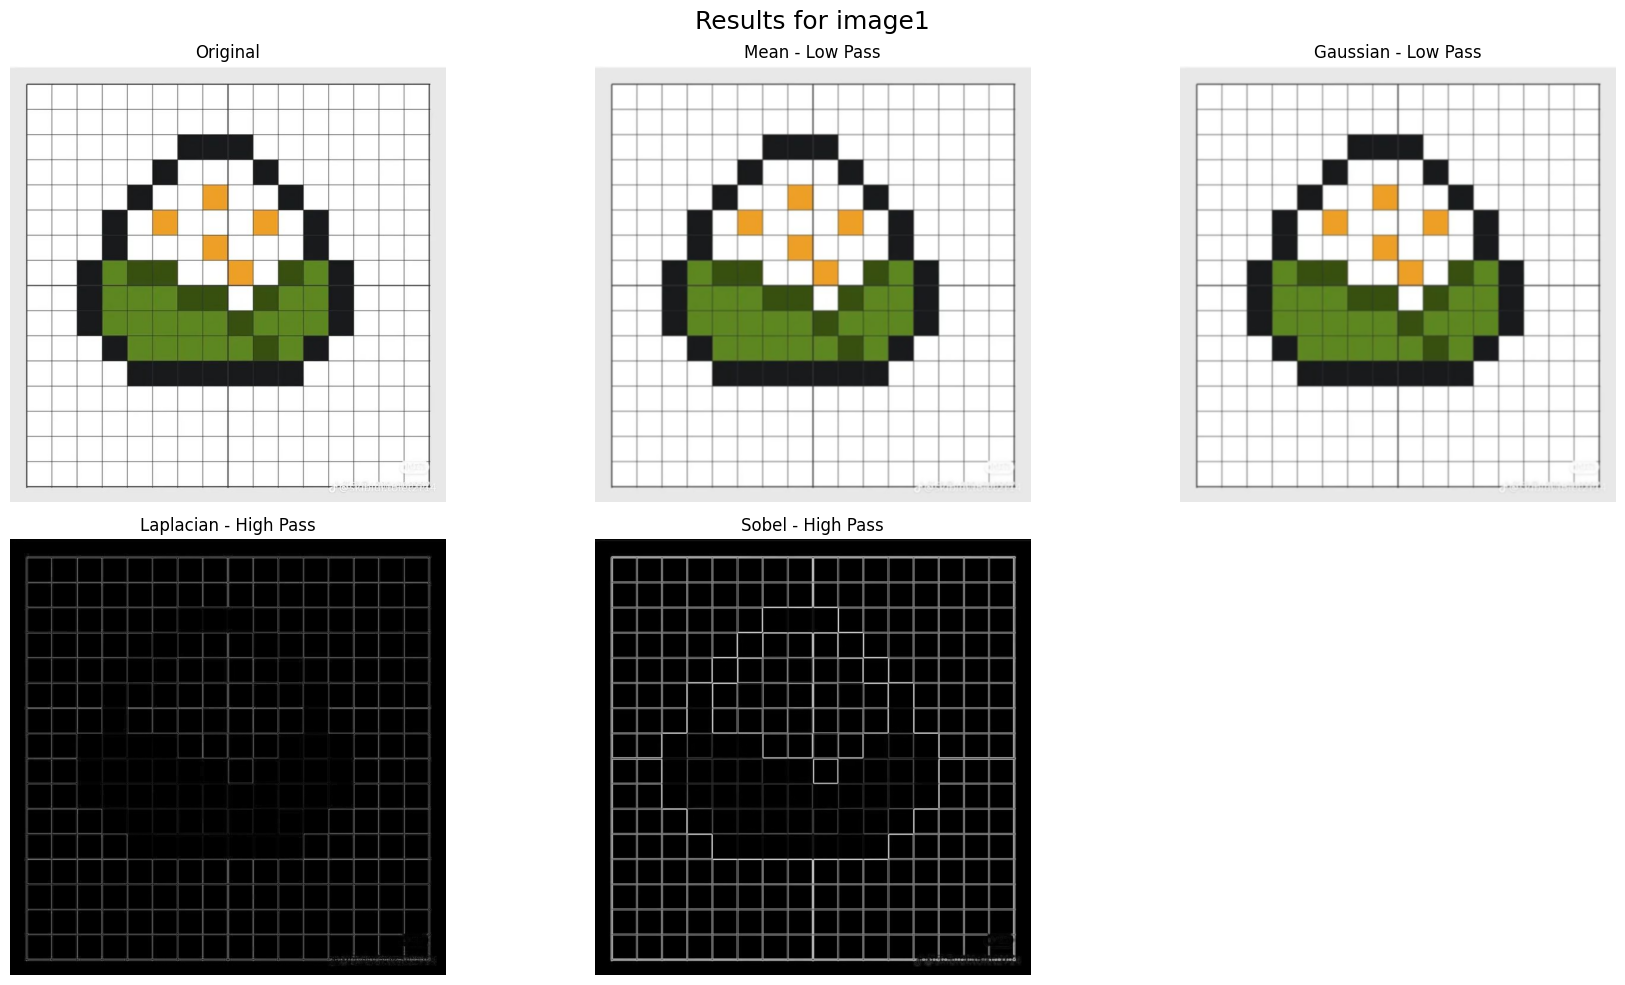

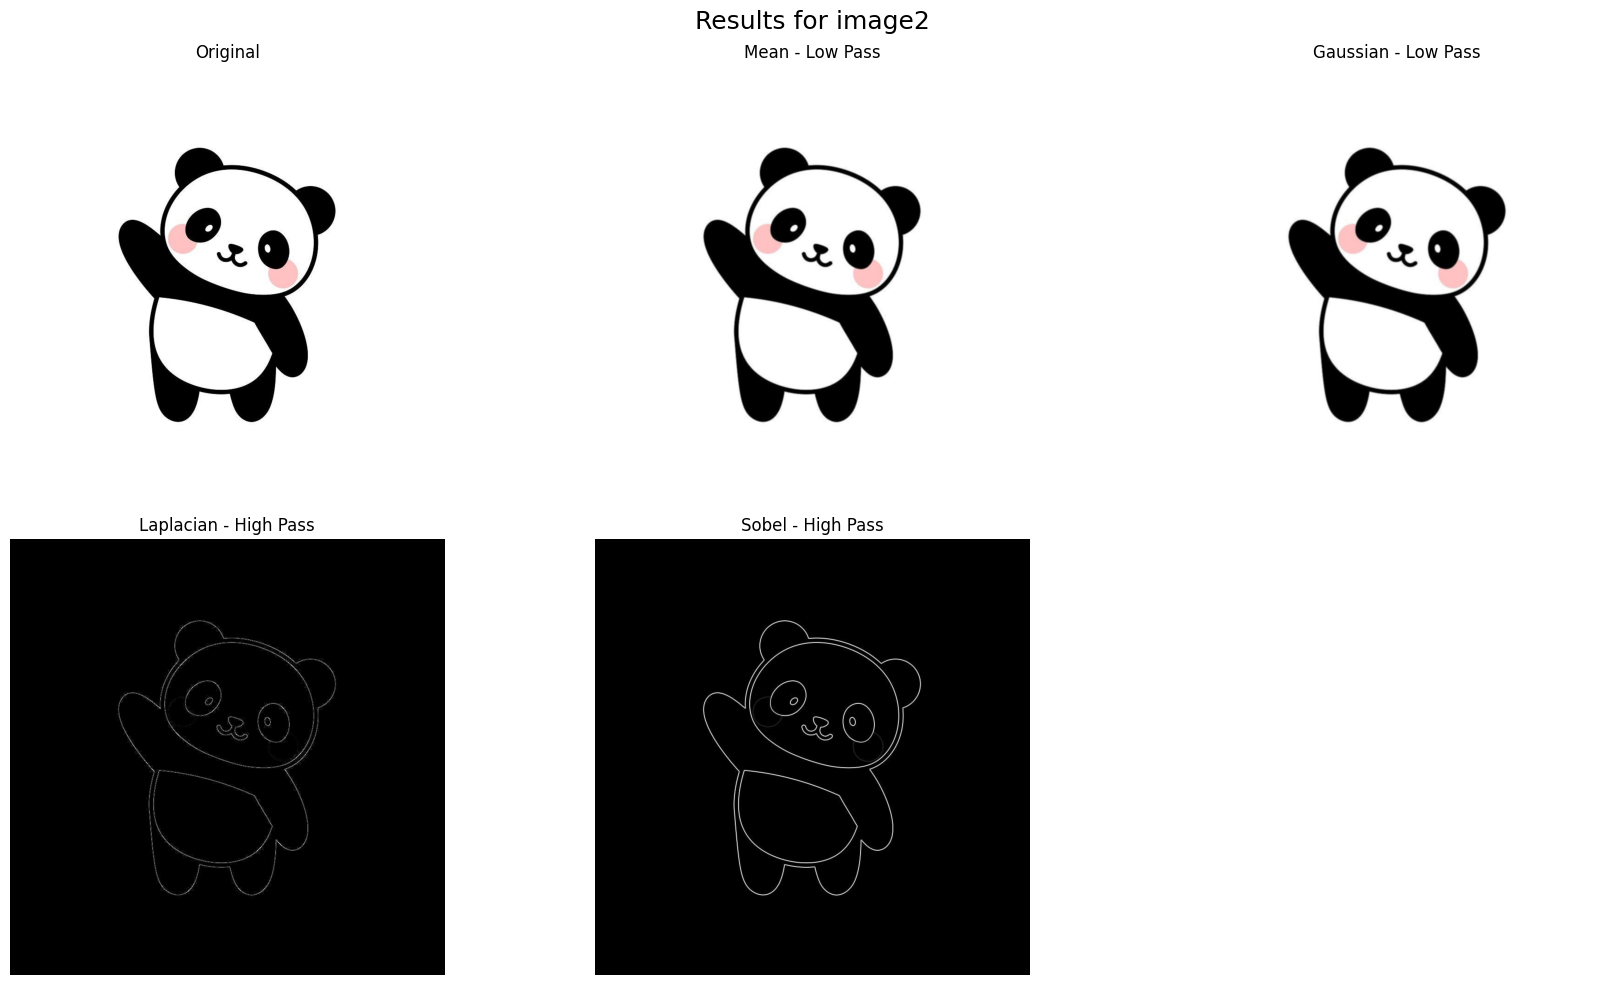

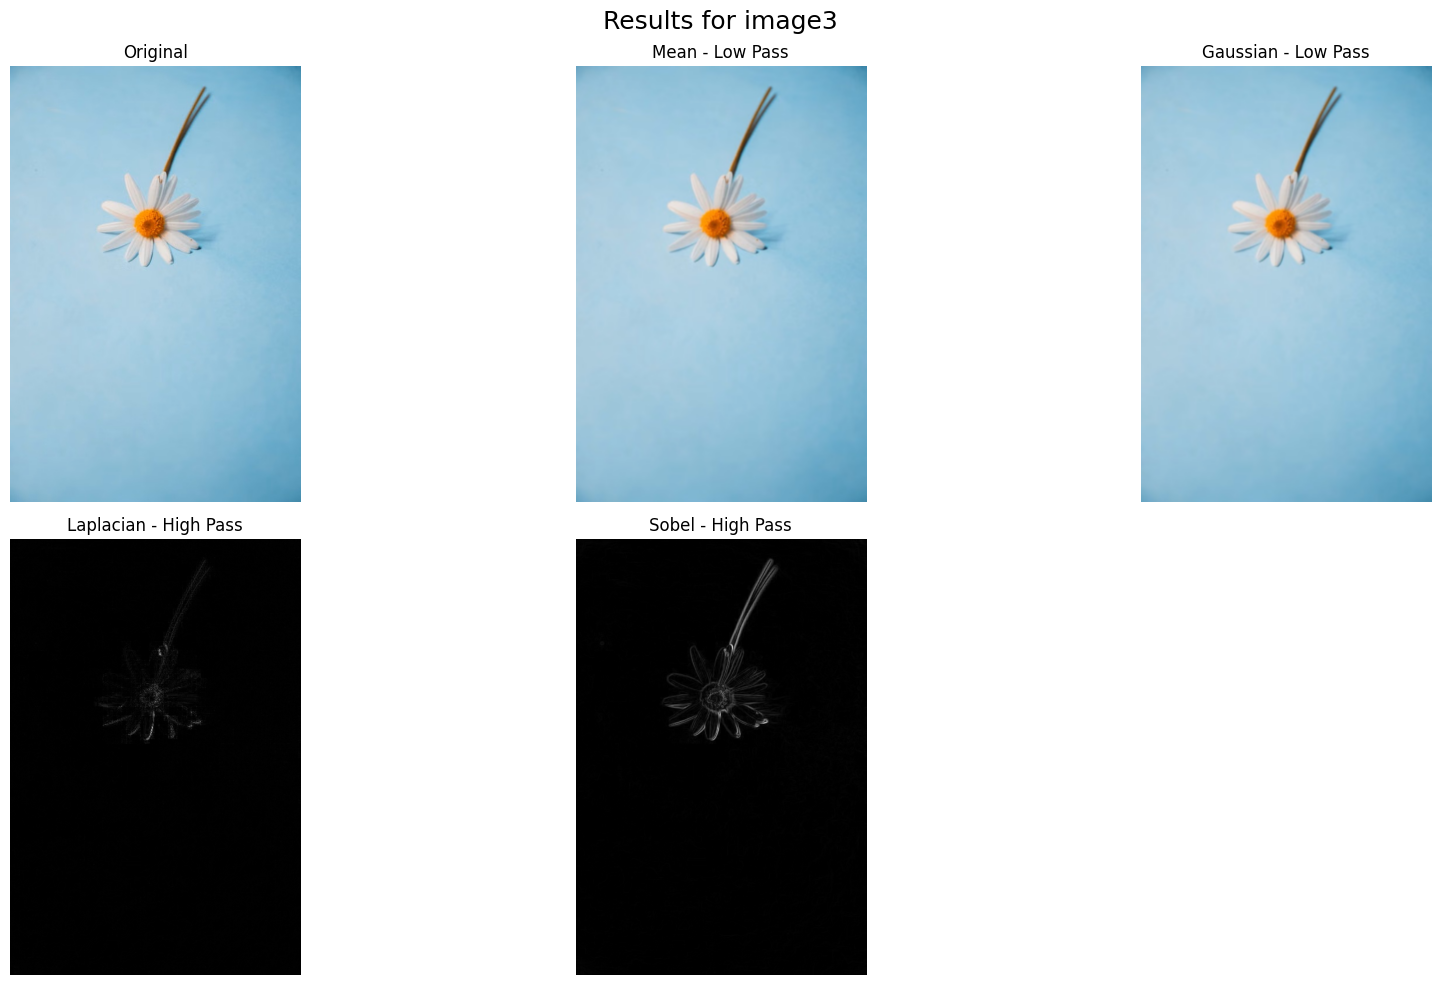

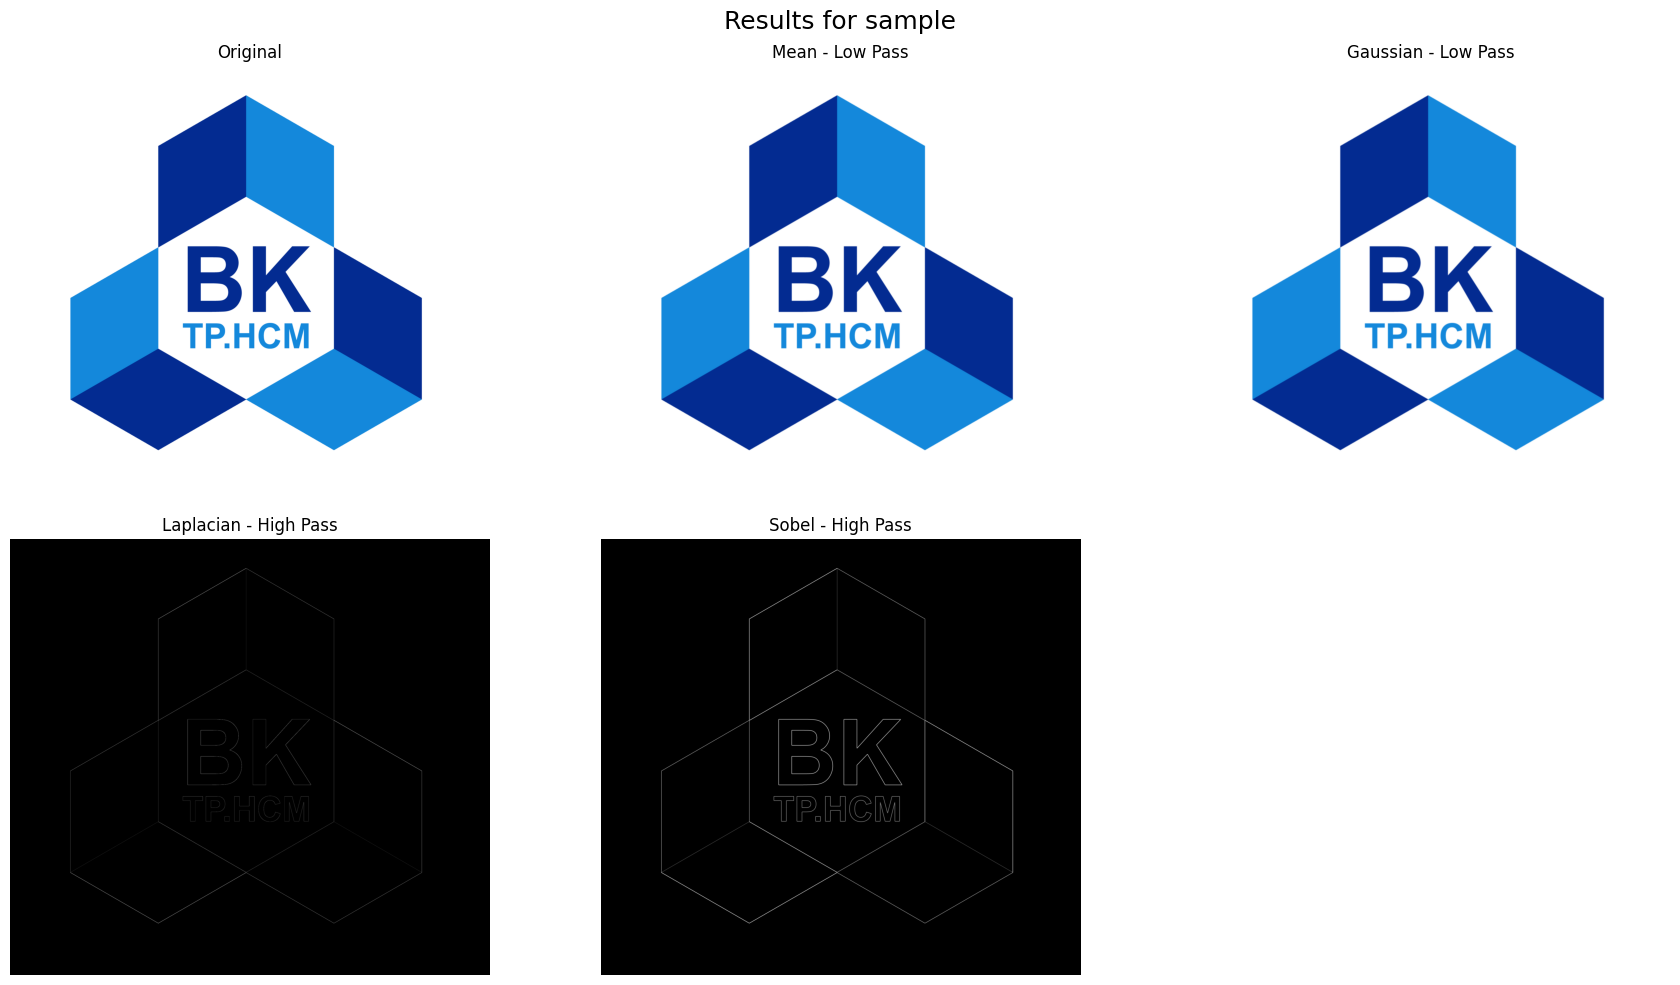

In [31]:
for path in image_paths:
    img_name = path.stem  
    
    img_rgb = load_image(path)
    results = apply_filters(img_rgb)
    display_and_save_results(results, image_name=img_name, output_dir="output")